In [47]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder , StandardScaler 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split , GridSearchCV , validation_curve , learning_curve
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score , roc_auc_score
from sklearn.linear_model import LinearRegression , Ridge , Lasso , ElasticNet 
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

In [48]:
df = pd.read_csv(r"C:\Users\Ameen\Desktop\MyProjects-P\New York City Airbnb\archive\AB_NYC_2019.csv")
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [49]:
print(df.info())

print("-" * 80)

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

EDA :

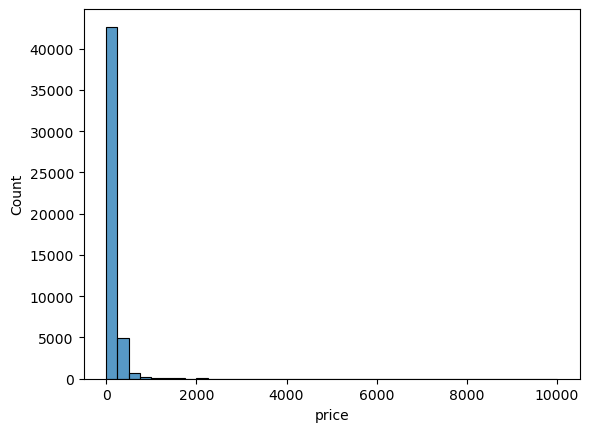

In [50]:
sns.histplot(df["price"] , bins=40)
plt.show()

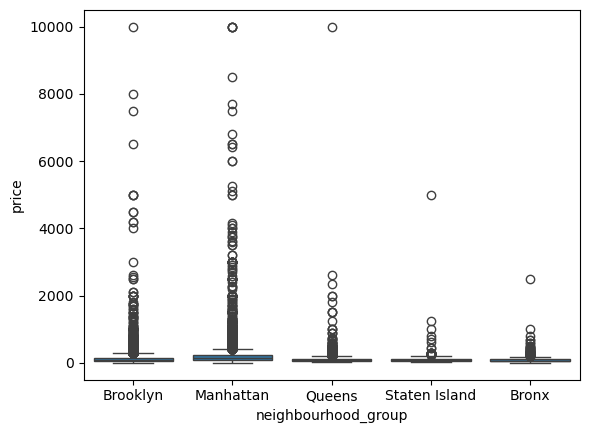

In [51]:
sns.boxplot(x="neighbourhood_group" , y="price" , data=df)
plt.show()

<Axes: xlabel='room_type', ylabel='price'>

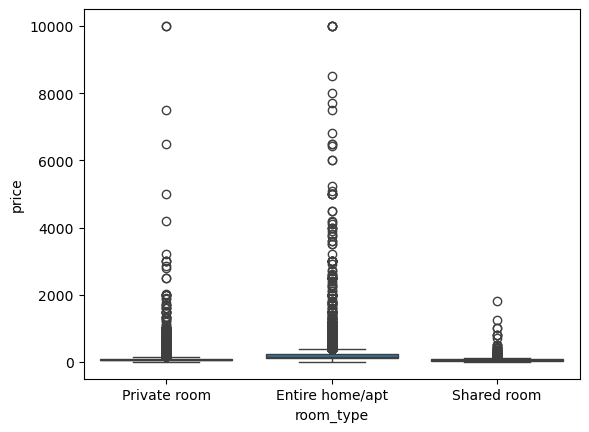

In [52]:
sns.boxplot(x="room_type" , y="price" , data=df)

<Axes: xlabel='number_of_reviews', ylabel='price'>

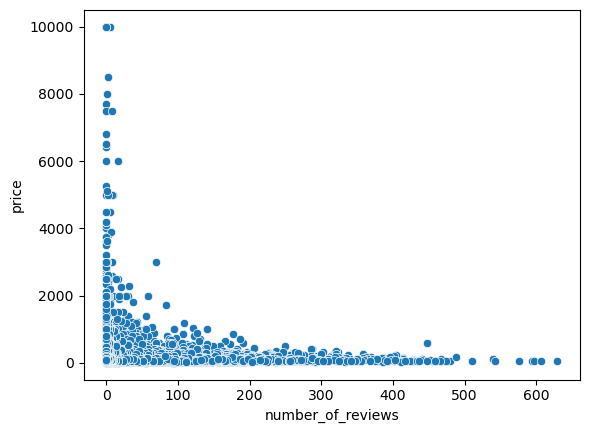

In [53]:
sns.scatterplot(x="number_of_reviews" , y="price" , data=df)

<Axes: xlabel='minimum_nights', ylabel='price'>

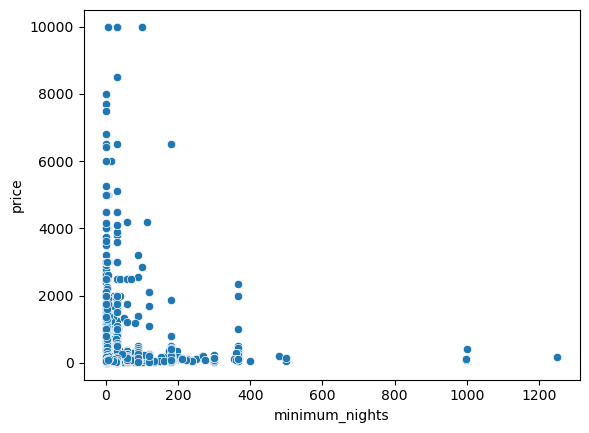

In [54]:
sns.scatterplot(x="minimum_nights" , y="price" , data=df)

<Axes: >

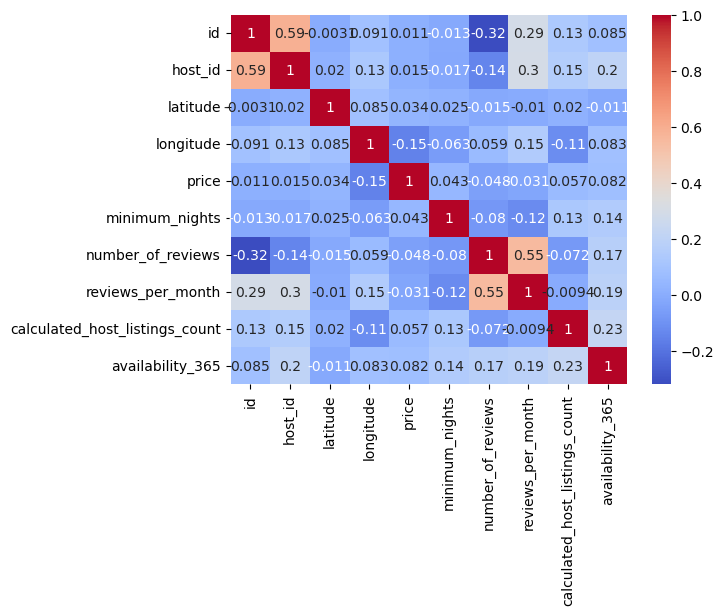

In [55]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr , annot=True , cmap="coolwarm")

Data Cleaning :

In [56]:
df["price"].quantile([0.90 , 0.95 , 0.99])

0.90    269.0
0.95    355.0
0.99    799.0
Name: price, dtype: float64

In [57]:
df["price"] = np.where(df["price"] > 1000 , 1000 , df["price"])
df["price"].describe()

count    48895.000000
mean       145.477288
std        130.950025
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max       1000.000000
Name: price, dtype: float64

In [58]:
df["price"] = np.log1p(df["price"])
df["price"].describe()

count    48895.000000
mean         4.733364
std          0.681265
min          0.000000
25%          4.248495
50%          4.672829
75%          5.170484
max          6.908755
Name: price, dtype: float64

In [59]:
del df["name"]
del df["host_id"]
del df["host_name"]

In [60]:
df.isnull().sum()

id                                    0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [61]:
df.fillna(0 , inplace = True)
df.isnull().sum()

id                                0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Feature Engineering :

In [62]:
df["neighbourhood_density"] = df.groupby("neighbourhood")["id"].transform("count")

df["multi_host"] = (df["calculated_host_listings_count"] > 3).astype(int)

df["review_score"] = df["number_of_reviews"] * df["reviews_per_month"]

df["demand_ratio"] = df["number_of_reviews"] / (df["availability_365"] + 1)

df["reviews_per_year"] = df["reviews_per_month"] * 12

df["room_demand"] = df["room_type"] + "_" + df["neighbourhood_group"]

df["distance_center"] = (
    (df["latitude"] - 40.7128) **2 + (df["longitude"] + 74.0060) **2
      ) **0.5

In [63]:
df["lat_bin"] = pd.cut(df["latitude"] , bins=10)
df["long_bin"] = pd.cut(df["longitude"] , bins=10)

kmeans = KMeans(n_clusters=10 , random_state=42)

df["geo_cluster"] = kmeans.fit_predict(df[["latitude" , "longitude"]])

In [64]:
center_lat = 40.7128
center_long = -74.0060

df["distance_center"] = np.sqrt(
    (df["latitude"] - center_lat) **2 +(df["longitude"] - center_long) **2
)

df["demand_score"] = df["number_of_reviews"] * df["reviews_per_month"]

df["availability_pressure"] = df["availability_365"] / (df["minimum_nights"] + 1)

df["host_power"] = (
    df["calculated_host_listings_count"] * df["availability_365"]
)

df["room_location"] = df["room_type"] + "_" + df["neighbourhood_group"]

df["area_demand"] = df["neighbourhood_density"] * df["reviews_per_month"]

In [65]:
num_features = [
    "minimum_nights" ,
    "number_of_reviews" ,
    "reviews_per_month" ,
    "availability_365" ,
    "calculated_host_listings_count" ,
    "latitude" ,
    "longitude"
]

cat_features = [
    "neighbourhood_group" ,
    "room_type" ,
    "room_demand"
]

In [66]:
cat_features += ["lat_bin" , "long_bin" , "geo_cluster"]
num_features += ["distance_center"]

In [67]:
cat_features += ["room_location"]
num_features += ["demand_score" , "availability_pressure" , "host_power" , "area_demand"]

Preprocessing :

In [68]:
x = df.drop("price" , axis=1)
y = df["price"]

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat" , OneHotEncoder(handle_unknown="ignore" , drop="first") , cat_features) ,
        ("num" , StandardScaler() , num_features) 
    ]
)

RX_train = preprocessor.fit_transform(x_train)
RX_test = preprocessor.transform(x_test)

models preparation :

In [69]:
all_models_results = []

In [70]:
def evaluate_regression_model(model , X_test , y_test , model_name = "Model"):
    # 1. التوقعات
    y_pred = model.predict(X_test)
    
    # 2. حساب المقاييس (Metrics)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # أو يمكن استخدام mean_squared_error(..., squared=False)
    r2 = r2_score(y_test, y_pred)
    
    # 3. إرجاع النتائج كـ Dictionary
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,      # اختياري، بس مفيد للمقارنة
        "R2_Score": r2
    }

In [71]:
def val_curves(model , x_train , y_train , param_name , cv , param_range):

    train_scores, test_scores = validation_curve(
        model , 
        x_train , 
        y_train , 
        param_name = param_name , 
        param_range = param_range ,
        cv = cv , 
        scoring = "neg_root_mean_squared_error" , 
        n_jobs = -1
    )

    train_mean = abs(np.mean(train_scores , axis=1))
    train_std = np.std(train_scores , axis=1)
    test_mean = abs(np.mean(test_scores , axis=1))
    test_std = np.std(test_scores , axis=1)

    plt.figure(figsize = (10, 6))
    plt.title("Validation Curve")
    plt.xlabel("param (Complexity)")
    plt.ylabel("RMSE Error (Lower is Better)")

    plt.plot(param_range, train_mean , label = "Training Error" , color = "darkorange", lw = 2 , marker = 'o')
    plt.fill_between(param_range, train_mean - train_std , train_mean + train_std , alpha = 0.1 , color = "darkorange")

    # رسم منطقة التيست
    plt.plot(param_range , test_mean , label = "Validation Error" , color = "navy" , lw = 2, marker = 'o')
    plt.fill_between(param_range , test_mean - test_std , test_mean + test_std , alpha = 0.1 , color = "navy")

    plt.legend(loc = "best")
    plt.grid()
    plt.show()

In [72]:
def model_score(model , xr_train , yr_train , xr_test , yr_test):
    model.fit(xr_train , yr_train)
    y_pred = model.predict(xr_test)

    mae = mean_absolute_error(yr_test , y_pred)
    print(f"MAE:  {mae}")

    rmse = np.sqrt(mean_squared_error(yr_test , y_pred))
    print(f"RMSE: {rmse}")

    r2 = r2_score(yr_test , y_pred)
    print(f"R2:   {r2}")

    mse = mean_squared_error(yr_test, y_pred)   
    print(f"MSE:  {mse}")         

    n = len(yr_test)
    p = xr_test.shape[1]   
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"Adj R2: {adj_r2}")

In [73]:
def learning_curves_reg(model , x_train , y_train , cv):

    train_sizes=np.linspace(0.1 , 1.0 , 5)

    train_sizes , train_scores , test_scores = learning_curve(
        model , 
        x_train , y_train ,
        cv = cv , n_jobs = -1 
    )

    train_mean = np.mean(train_scores , axis = 1)
    train_std  = np.std(train_scores , axis = 1)
    test_mean  = np.mean(test_scores , axis = 1)
    test_std   = np.std(test_scores , axis = 1)

    plt.figure()
    plt.title("Learning Curve (Full Data)")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    #  المعادله هاي عشان ارسم التباين
    plt.fill_between(train_sizes , train_mean - train_std , train_mean + train_std , alpha = 0.1 , color = "r")
    plt.fill_between(train_sizes , test_mean - test_std , test_mean + test_std , alpha = 0.1 , color = "g")

    plt.plot(train_sizes , train_mean , 'o-' , color = "r" , label = "Training score")
    plt.plot(train_sizes , test_mean , 'o-' , color = "g" , label = "Cross-validation score")

    plt.legend(loc = "best")
    plt.show()

LR :

In [74]:
LR_pipline = make_pipeline(
    preprocessor ,
    ElasticNet(random_state = 42)
)

LR_param_grid = {
    "elasticnet__alpha": [0.001 , 0.01 , 0.1 , 1 , 10] ,
    "elasticnet__l1_ratio": [0 , 0.1 , 0.5 , 0.7 , 0.9 , 1.0] ,
    "elasticnet__max_iter": [1000 , 5000]
}

LR_grid_search = GridSearchCV(
    estimator = LR_pipline ,
    param_grid = LR_param_grid ,
    cv = 5 ,
    scoring = "r2" ,
    n_jobs = -1
)

LR_grid_search.fit(x_train , y_train)

print("\nBest Score:", LR_grid_search.best_score_)
print("Best Parameters:", LR_grid_search.best_params_)


Best Score: 0.5458683946696963
Best Parameters: {'elasticnet__alpha': 0.001, 'elasticnet__l1_ratio': 0, 'elasticnet__max_iter': 1000}


c:\Users\Ameen\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.148e+03, tolerance: 1.820e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.sparse_enet_coordinate_descent(


In [75]:
best_Alpha = LR_grid_search.best_params_["elasticnet__alpha"]
best_L1_Ratio = LR_grid_search.best_params_["elasticnet__l1_ratio"]
best_MI = LR_grid_search.best_params_["elasticnet__max_iter"]


final_LR_pipline = make_pipeline(
    preprocessor ,
    ElasticNet(alpha = best_Alpha , l1_ratio = best_L1_Ratio , max_iter = best_MI , random_state = 42)
)

model_score(final_LR_pipline , x_train , y_train , x_test , y_test)


train_score = final_LR_pipline.score(x_train , y_train)
test_score  = final_LR_pipline.score(x_test , y_test)

print(f"\nTraining R2: {train_score:.4f}")
print(f"Test R2:     {test_score:.4f}")
print(f"Difference:  {train_score - test_score:.4f}")

MAE:  0.33395590349129195
RMSE: 0.4521225995422113
R2:   0.554618706553951
MSE:  0.20441484501680673
Adj R2: 0.5533854694579564

Training R2: 0.5472
Test R2:     0.5546
Difference:  -0.0074


c:\Users\Ameen\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.148e+03, tolerance: 1.820e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.sparse_enet_coordinate_descent(


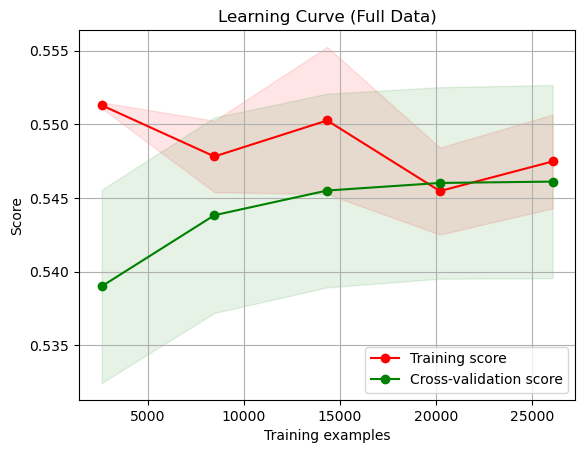

In [76]:
learning_curves_reg(final_LR_pipline , x_train , y_train , 3)

In [77]:
results_LoR = evaluate_regression_model(final_LR_pipline , x_test , y_test , model_name = "linear Regression")

all_models_results.append(results_LoR)

RF :

In [78]:
RF_pipline = make_pipeline(
    preprocessor ,
    RandomForestRegressor(random_state = 42)
)

RF_param_grid = {
    "randomforestregressor__n_estimators": [200] ,
    "randomforestregressor__max_depth": [10 , 15] ,
    "randomforestregressor__min_samples_leaf": [3 , 5 , 10] ,
    "randomforestregressor__min_samples_split": [5 , 10 , 15]
}

RF_grid_search = GridSearchCV(
    estimator = RF_pipline ,
    param_grid = RF_param_grid ,
    cv = 3 ,
    scoring = "r2" ,
    n_jobs = -1
)

RF_grid_search.fit(x_train , y_train)

print("\nBest Score:", RF_grid_search.best_score_)
print("Best Parameters:", RF_grid_search.best_params_)


Best Score: 0.6111143033314864
Best Parameters: {'randomforestregressor__max_depth': 15, 'randomforestregressor__min_samples_leaf': 3, 'randomforestregressor__min_samples_split': 5, 'randomforestregressor__n_estimators': 200}


In [79]:
best_N = RF_grid_search.best_params_["randomforestregressor__n_estimators"]
best_MD = RF_grid_search.best_params_[ "randomforestregressor__max_depth"]
best_MSL = RF_grid_search.best_params_["randomforestregressor__min_samples_leaf"]
best_MSS = RF_grid_search.best_params_["randomforestregressor__min_samples_split"]


final_RF_pipline = make_pipeline(
    preprocessor ,
    RandomForestRegressor(n_estimators = best_N , max_depth = best_MD , 
                          min_samples_leaf = best_MSL , min_samples_split = best_MSS ,
                          max_features = 0.5 , random_state = 42)
)

model_score(final_RF_pipline , x_train , y_train , x_test , y_test)


train_score = final_RF_pipline.score(x_train , y_train)
test_score  = final_RF_pipline.score(x_test , y_test)

print(f"\nTraining R2: {train_score:.4f}")
print(f"Test R2:     {test_score:.4f}")
print(f"Difference:  {train_score - test_score:.4f}")

MAE:  0.298979762343669
RMSE: 0.4104473125298222
R2:   0.6329422712086588
MSE:  0.16846699636295354
Adj R2: 0.6319259078943971

Training R2: 0.7813
Test R2:     0.6329
Difference:  0.1484


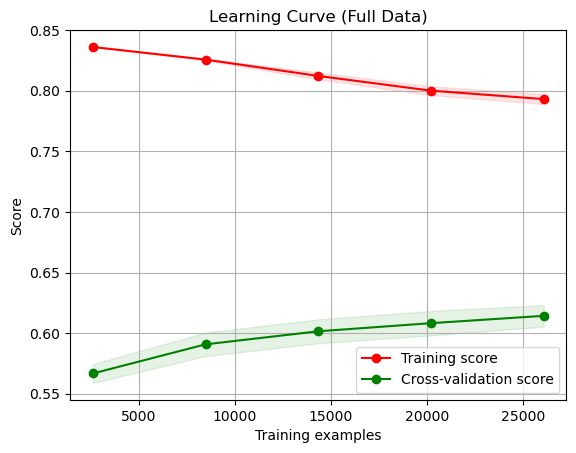

In [80]:
learning_curves_reg(final_RF_pipline , x_train , y_train , 3)

In [81]:
model = final_RF_pipline.named_steps["randomforestregressor"]

importances = model.feature_importances_

feat_names = final_RF_pipline.named_steps["columntransformer"].get_feature_names_out()

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

print(feat_imp.head(15))

cat__room_type_Private room                     0.194559
cat__room_demand_Entire home/apt_Manhattan      0.088845
cat__room_location_Entire home/apt_Manhattan    0.086821
num__distance_center                            0.083496
num__longitude                                  0.070078
num__latitude                                   0.053511
num__availability_pressure                      0.042402
cat__room_location_Entire home/apt_Brooklyn     0.040889
cat__room_type_Shared room                      0.037521
cat__room_demand_Entire home/apt_Brooklyn       0.034665
num__availability_365                           0.028173
num__host_power                                 0.026688
num__minimum_nights                             0.024110
num__area_demand                                0.021606
num__demand_score                               0.021128
dtype: float64


In [82]:
model = final_RF_pipline.named_steps["randomforestregressor"]

importances = model.feature_importances_
feature_names = final_RF_pipline.named_steps["columntransformer"].get_feature_names_out()

feat_imp = pd.Series(importances , index=feature_names)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

X_train_df = pd.DataFrame(RX_train.toarray() , columns=feature_names)
X_test_df  = pd.DataFrame(RX_test.toarray() , columns=feature_names)

for k in [20 , 30 , 40 , 50]:
    selected = feat_imp_sorted.head(k).index
    
    X_train_selected = X_train_df[selected]
    X_test_selected  = X_test_df[selected]
    
    model_k = RandomForestRegressor(random_state=42)
    model_k.fit(X_train_selected, y_train)
    
    train_score = model_k.score(X_train_selected , y_train)
    test_score  = model_k.score(X_test_selected , y_test)
    
    print(f"Top {k} → Train: {train_score:.3f} | Test: {test_score:.3f}")

Top 20 → Train: 0.945 | Test: 0.626
Top 30 → Train: 0.945 | Test: 0.624
Top 40 → Train: 0.945 | Test: 0.622
Top 50 → Train: 0.945 | Test: 0.623


In [83]:
selected = feat_imp_sorted.head(20).index

X_train_selected = X_train_df[selected]
X_test_selected  = X_test_df[selected]

model_k = RandomForestRegressor(
    n_estimators = 300 ,
    max_depth = 15 ,          
    min_samples_split = 5 ,   
    min_samples_leaf = 2 ,    
    max_features = "sqrt" ,
    random_state = 42
)

model_k.fit(X_train_selected , y_train)

print("Train:", model_k.score(X_train_selected , y_train))
print("Test :", model_k.score(X_test_selected , y_test))

Train: 0.764600827006747
Test : 0.6305847695264817


In [84]:
results_RF = evaluate_regression_model(final_RF_pipline , x_test , y_test , model_name = "Random Forest")

all_models_results.append(results_RF)

XGBoost :

In [85]:
xgb_pipeline = make_pipeline(
    preprocessor ,
    XGBRegressor(
        objective = 'reg:squarederror' ,
        random_state = 42 ,
        n_jobs = -1
    )
)

xgb_param_grid = {
    "xgbregressor__n_estimators": [200 , 300] ,
    "xgbregressor__learning_rate": [0.03 , 0.05 , 0.1] ,
    "xgbregressor__max_depth": [4 , 5 , 6] ,
    "xgbregressor__subsample": [0.8 , 0.9 , 1.0] ,
    "xgbregressor__colsample_bytree": [0.8 , 0.9 , 1.0]
}

XGB_grid_search = GridSearchCV(
    estimator = xgb_pipeline ,
    param_grid = xgb_param_grid ,
    cv = 3 ,
    scoring = "r2" ,
    n_jobs = -1 ,
    verbose = 1
)

XGB_grid_search.fit(x_train , y_train)

print("\nBest Score:", XGB_grid_search.best_score_)
print("Best Parameters:", XGB_grid_search.best_params_)

Fitting 3 folds for each of 162 candidates, totalling 486 fits

Best Score: 0.6190852754281447
Best Parameters: {'xgbregressor__colsample_bytree': 0.9, 'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 6, 'xgbregressor__n_estimators': 300, 'xgbregressor__subsample': 0.9}


In [86]:
best_n_est = XGB_grid_search.best_params_["xgbregressor__n_estimators"]
best_lr    = XGB_grid_search.best_params_["xgbregressor__learning_rate"]
best_depth = XGB_grid_search.best_params_["xgbregressor__max_depth"]
best_sub = XGB_grid_search.best_params_["xgbregressor__subsample"]
best_col = XGB_grid_search.best_params_["xgbregressor__colsample_bytree"]

final_XGB_pipline = make_pipeline(
    preprocessor ,
    XGBRegressor(
        n_estimators = best_n_est ,
        learning_rate = best_lr ,
        max_depth = best_depth ,
        subsample = best_sub ,                
        colsample_bytree = best_col ,        
        objective = 'reg:squarederror' ,
        random_state = 42 ,
        n_jobs = -1
    )
)

final_XGB_pipline.fit(x_train , y_train)

print("Train:", final_XGB_pipline.score(x_train , y_train))
print("Test :", final_XGB_pipline.score(x_test , y_test))

Train: 0.6943020552832637
Test : 0.6384122250829052


In [87]:
results_xgb = evaluate_regression_model(final_XGB_pipline , x_test , y_test ,  model_name = "XGBoost")

all_models_results.append(results_xgb)

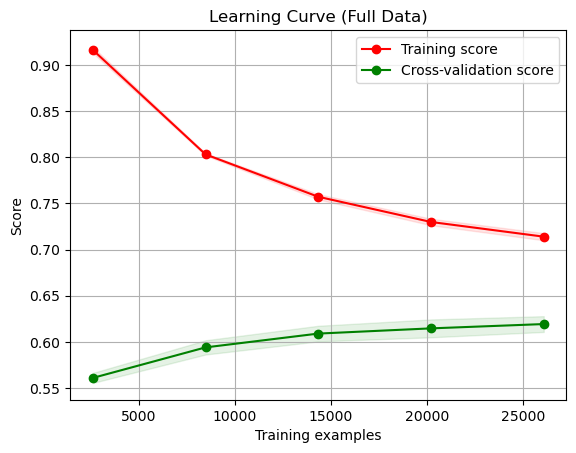

In [88]:
learning_curves_reg(final_XGB_pipline , x_train , y_train , 3)

In [89]:
reg_comparison_df = pd.DataFrame(all_models_results)

cols_to_convert = ['RMSE' , 'MAE' , 'MSE' , 'R2_Score']

existing_cols = [col for col in cols_to_convert if col in reg_comparison_df.columns]

reg_comparison_df[existing_cols] = reg_comparison_df[existing_cols].apply(pd.to_numeric , errors='coerce')

reg_comparison_df = reg_comparison_df.round(4)

if 'RMSE' in reg_comparison_df.columns:
    reg_comparison_df = reg_comparison_df.sort_values(by='RMSE' , ascending=True).reset_index(drop=True)

def highlight_cols(x):
    df_colors = pd.DataFrame('' , index=x.index, columns=x.columns)
    
    for col in ['RMSE' , 'MAE' , 'MSE']:
        if col in x.columns:
            is_min = x[col] == x[col].min()
            df_colors.loc[is_min , col] = 'background-color: green; font-weight: bold'
            
    if 'R2_Score' in x.columns:
        is_max = x['R2_Score'] == x['R2_Score'].max()
        df_colors.loc[is_max, 'R2_Score'] = 'background-color: green; font-weight: bold'
        
    return df_colors

styled_reg_df = reg_comparison_df.style.apply(highlight_cols , axis=None)

styled_reg_df

,Model,RMSE,MAE,MSE,R2_Score
0,XGBoost,0.407400,0.298000,0.166000,0.638400
1,Random Forest,0.410400,0.299000,0.168500,0.632900
2,linear Regression,0.452100,0.334000,0.204400,0.554600


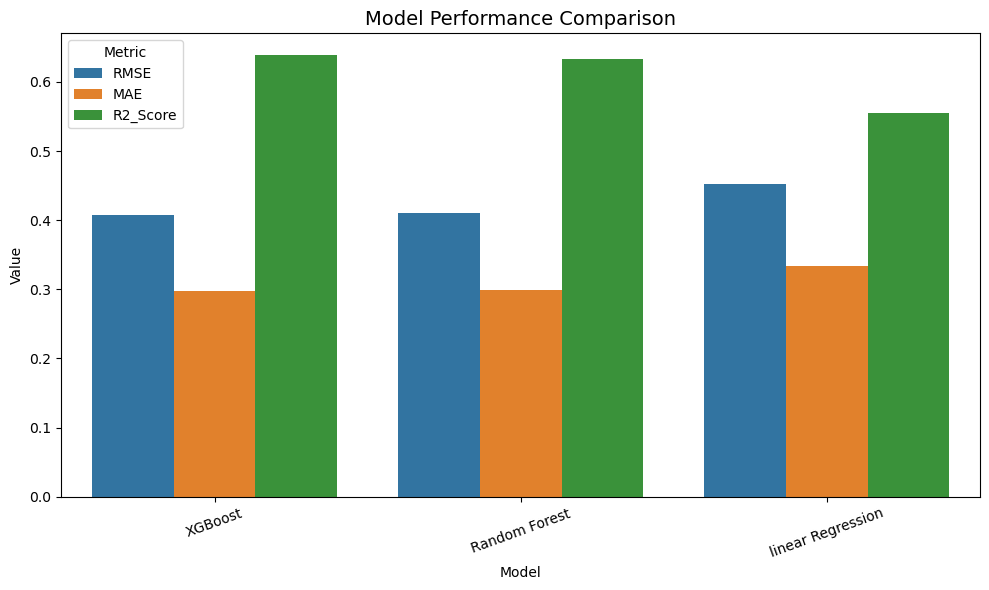

In [90]:
plt.figure(figsize=(10,6))

metrics = ["RMSE", "MAE", "R2_Score"]

reg_melted = reg_comparison_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Value"
)

sns.barplot(
    data=reg_melted,
    x="Model",
    y="Value",
    hue="Metric"
)

plt.title("Model Performance Comparison", fontsize=14)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()